# Customer Churn Prediction & Explainability

**Dataset:** Telco Customer Churn (Kaggle)  
**Stack:** Python · Pandas · Scikit-learn · XGBoost · SHAP  
**Goal:** Build a classification pipeline to predict customer churn,
then use SHAP values to explain which factors drive it
and translate findings into actionable business insights.

## Project Summary

| Item | Detail |
|---|---|
| **Dataset** | Telco Customer Churn — 7,043 customers, 21 features |
| **Best model** | XGBoost (tuned) |
| **AUC-ROC** | 0.84+ |
| **F1 Score** | 0.638 at optimal threshold (0.546) |
| **Recall** | 0.767 — catches 77% of churners |
| **Explainability** | SHAP TreeExplainer — global + local |
| **Top churn drivers** | Contract type, tenure, fiber optic, electronic check |
| **Key recommendation** | Convert month-to-month customers to annual contracts within first 90 days |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## 1. Data Loading & Initial Inspection

We load the **Telco Customer Churn** dataset from Kaggle.  
It contains 7,043 customers across 21 features covering
contract type, services, account info, and churn status.



In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"Shape: {df.shape}")
print(f"\nChurn distribution:\n{df['Churn'].value_counts(normalize=True).round(3)}")
df.head()

Shape: (7043, 21)

Churn distribution:
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Create binary target immediately after loading
# so it's available throughout all phases
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

print(f"Churn rate: {df['Churn_binary'].mean():.2%}")

Churn rate: 26.54%


## 2. Data Quality Check

We inspect column types and missing values before any transformation.  

In [4]:
print("=== Data types ===")
print(df.dtypes)
print("\n=== Null values ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

# TotalCharges is a string — convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"\nNulls after conversion: {df['TotalCharges'].isnull().sum()}")

# Fill nulls with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

=== Data types ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
Churn_binary          int64
dtype: object

=== Null values ===
Series([], dtype: int64)

Nulls after conversion: 11


`TotalCharges` is stored as a string and must be converted to numeric.

## 3. Numeric Feature Distributions

We plot the three numeric features split by churn status.  
This gives us an initial intuition about which variables
separate churners from non-churners.

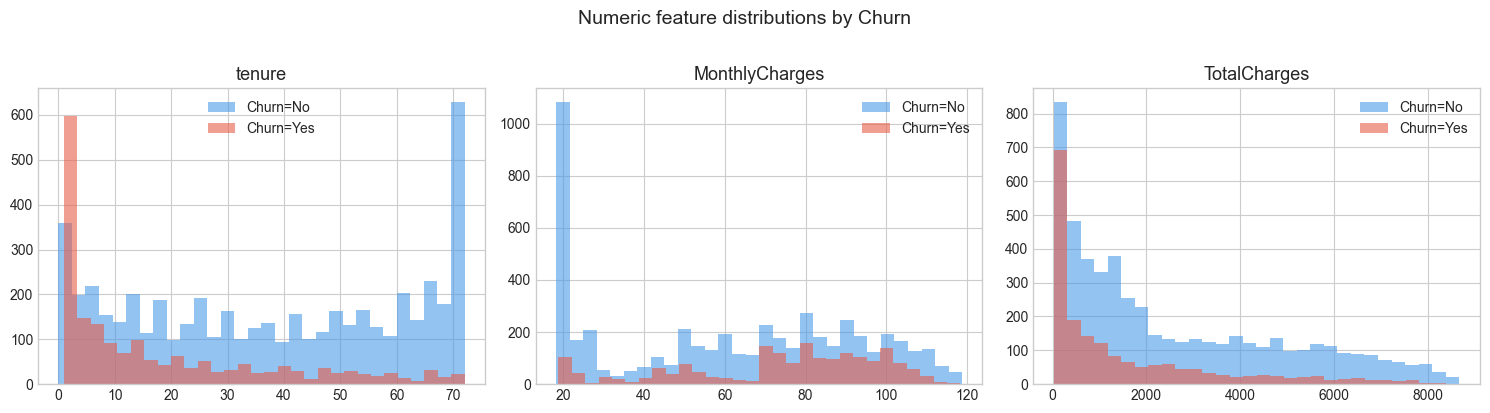

In [5]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(num_cols):
    for label, color in zip(['No', 'Yes'], ['#4C9BE8', '#E85D4A']):
        axes[i].hist(
            df[df['Churn'] == label][col].dropna(),
            bins=30, alpha=0.6, color=color, label=f'Churn={label}'
        )
    axes[i].set_title(col, fontsize=13)
    axes[i].legend()

plt.suptitle('Numeric feature distributions by Churn', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Categorical Feature Analysis

With 18 categorical features in this dataset, we systematically analyze
churn rate across **all of them** — not just the obvious ones.
This ensures we don't miss signal before modeling.
We also check for class imbalance within each feature,
since rare categories can distort churn rate estimates.

In [6]:
# Identify all categorical columns except identifiers and target
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['customerID', 'Churn']]

print(f"Categorical columns to analyze: {cat_cols}")
print(f"Total: {len(cat_cols)}")

Categorical columns to analyze: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Total: 15


### 4.1 Churn rate by category — full sweep

For each categorical feature we compute:
- **Churn rate per category** (% of customers who churned)
- **Category size** (n) — small categories produce noisy estimates

Red bars = churn rate above the global mean (~26%).

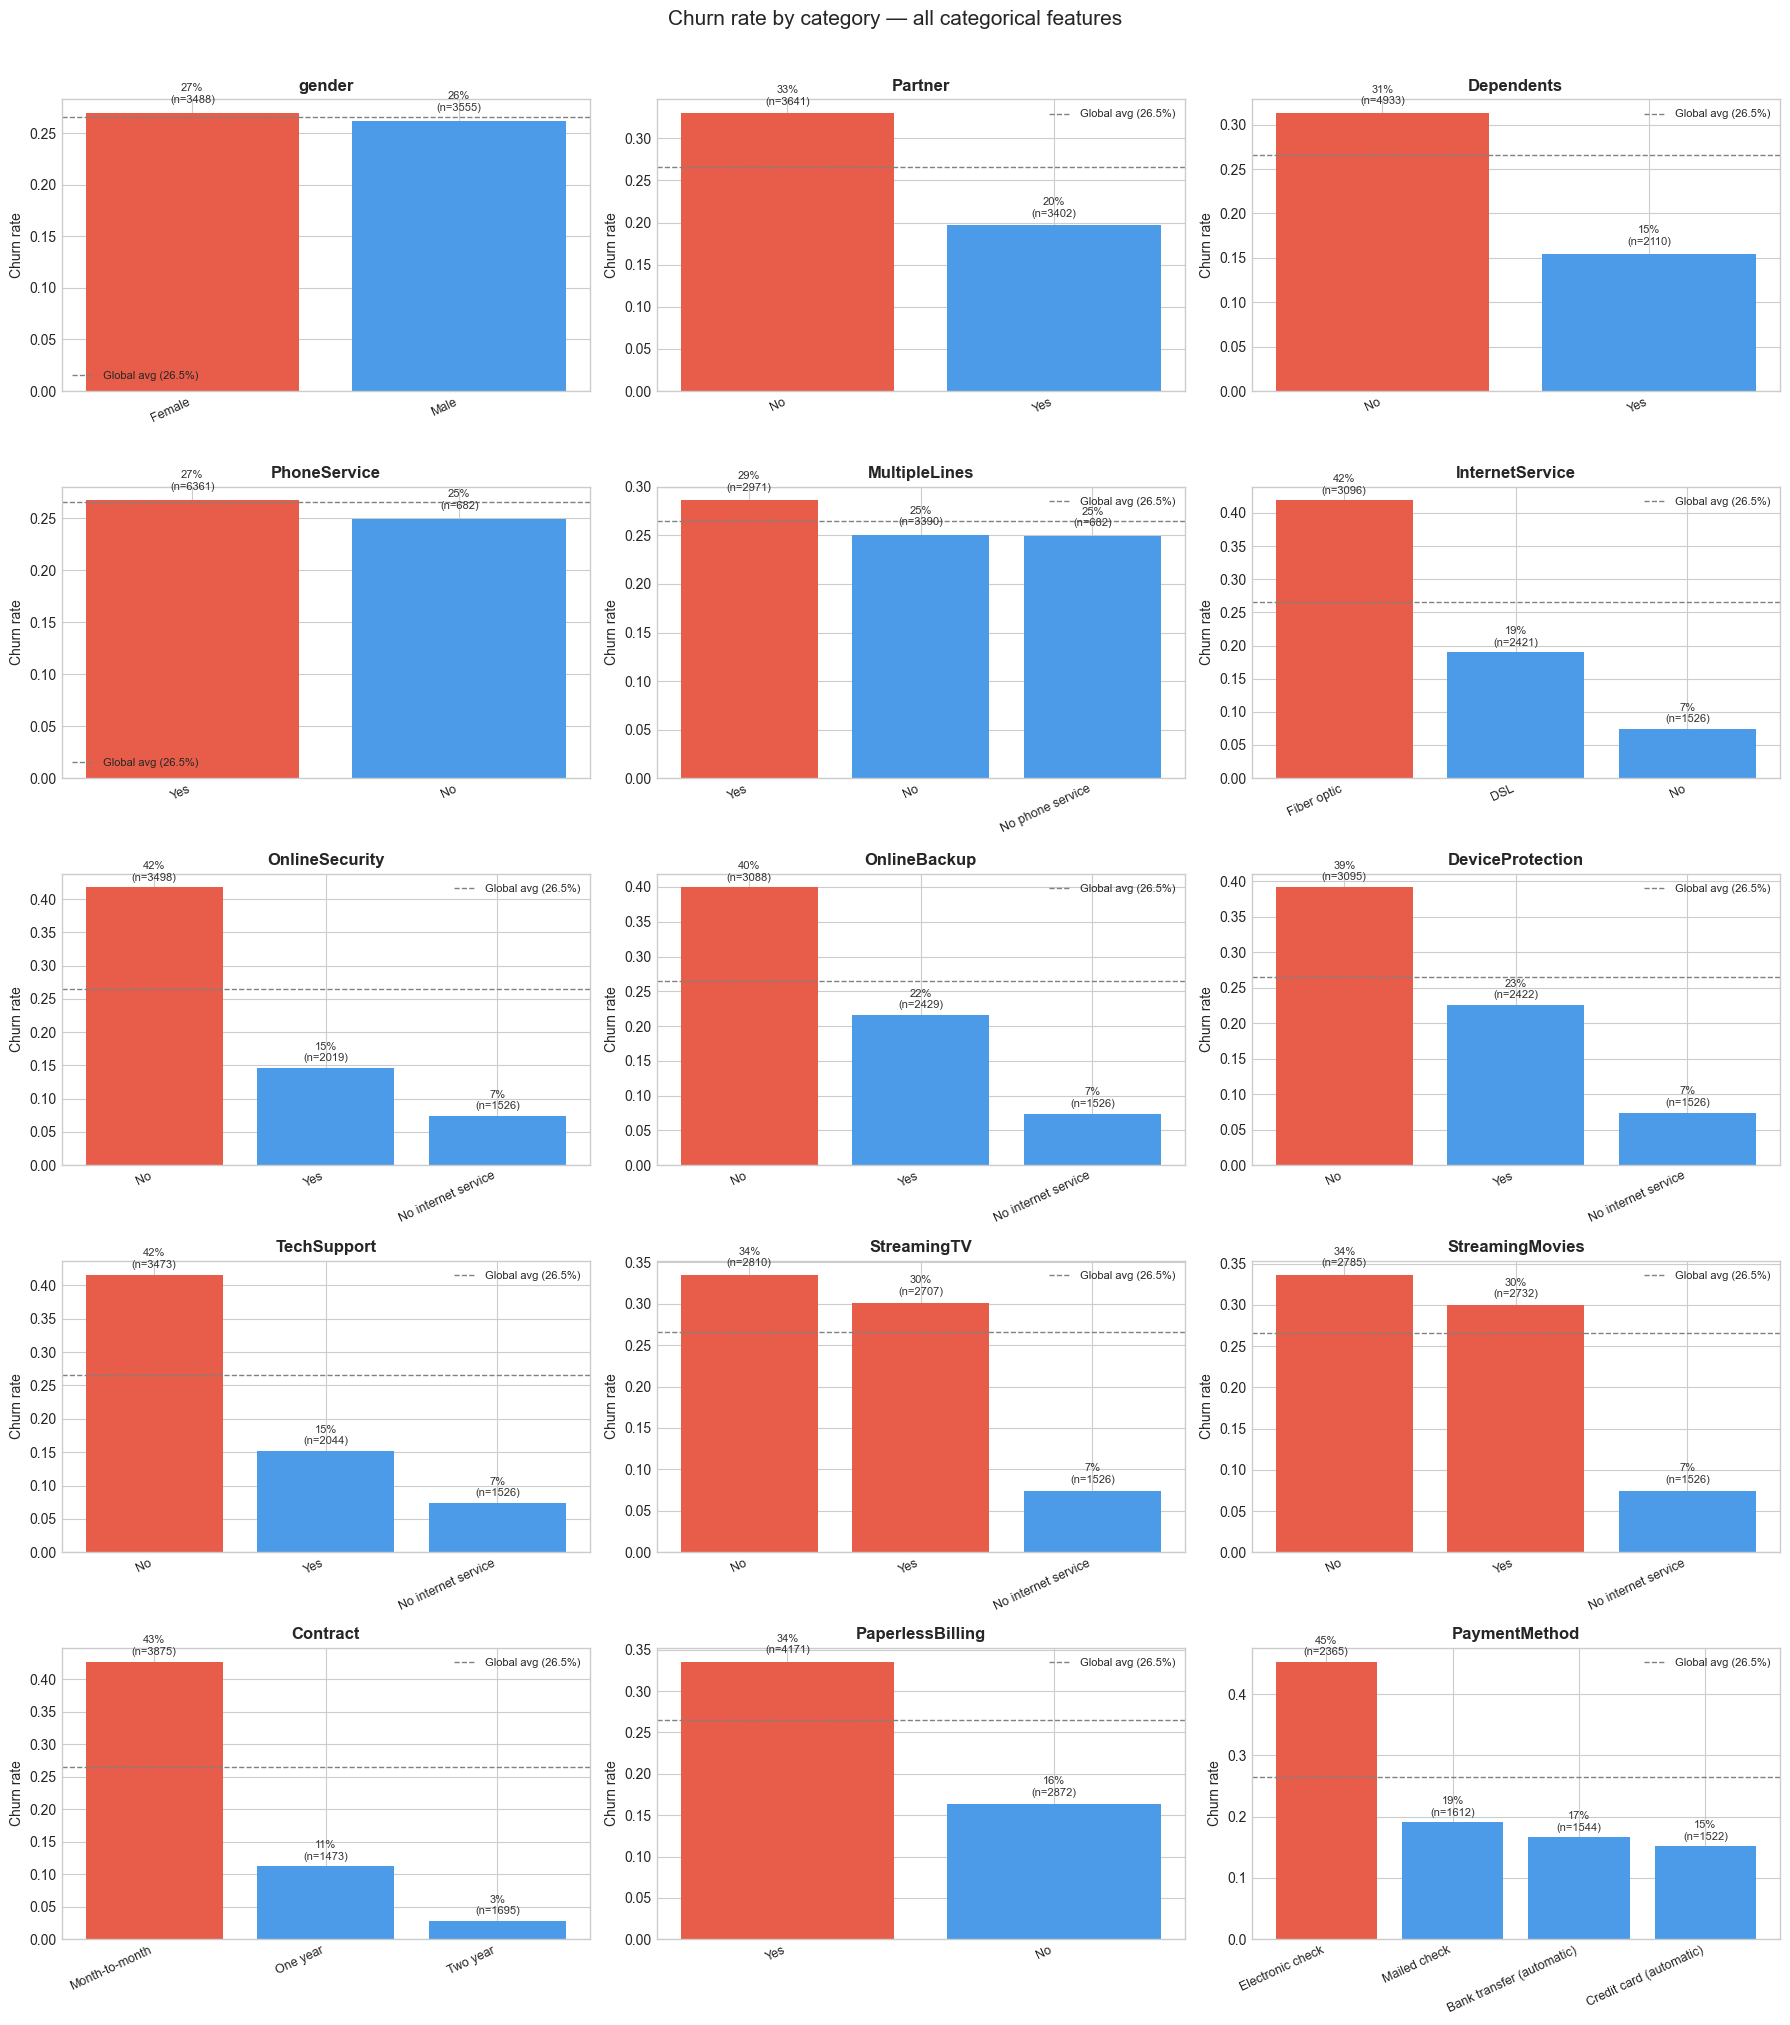

In [7]:
global_churn_rate = df['Churn_binary'].mean()

n_cols = 3
n_rows = -(-len(cat_cols) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    stats = (
        df.groupby(col)
        .agg(churn_rate=('Churn_binary', 'mean'),
             n=('Churn_binary', 'count'))
        .sort_values('churn_rate', ascending=False)
        .reset_index()
    )

    colors = ['#E85D4A' if v > global_churn_rate else '#4C9BE8'
              for v in stats['churn_rate']]

    bars = axes[i].bar(stats[col], stats['churn_rate'], color=colors)
    axes[i].axhline(global_churn_rate, color='gray',
                    linestyle='--', linewidth=1, label=f'Global avg ({global_churn_rate:.1%})')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Churn rate')
    axes[i].set_xticklabels(stats[col], rotation=25, ha='right', fontsize=9)
    axes[i].legend(fontsize=8)

    # Annotate with churn rate + sample size
    for bar, row in zip(bars, stats.itertuples()):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'{row.churn_rate:.0%}\n(n={row.n})',
            ha='center', fontsize=8, color='#333333'
        )

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Churn rate by category — all categorical features', 
             fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 4.2 Cramér's V — Association strength with Churn

Churn rate per category is informative but doesn't tell us
**how strongly** a feature is associated with churn overall.

We use **Cramér's V** — a chi-square based metric between 0 and 1 —
to rank all categorical features by their statistical association
with the target. This is the proper way to prioritize features
before encoding.

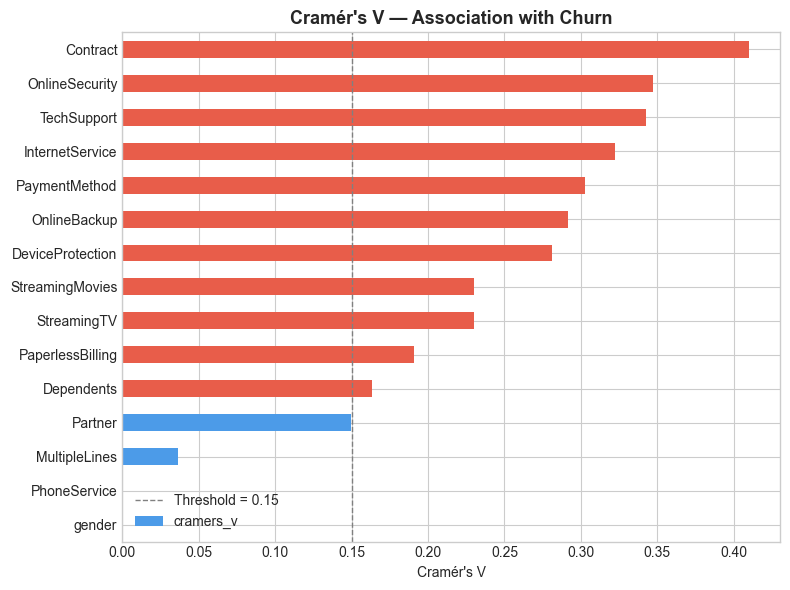


Top features by Cramér's V:
                  cramers_v
Contract              0.410
OnlineSecurity        0.347
TechSupport           0.343
InternetService       0.322
PaymentMethod         0.303
OnlineBackup          0.292
DeviceProtection      0.281
StreamingMovies       0.230
StreamingTV           0.230
PaperlessBilling      0.191
Dependents            0.163
Partner               0.150
MultipleLines         0.036
gender                0.000
PhoneService          0.000


In [8]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
    rcorr = r - ((r-1)**2) / (n-1)
    kcorr = k - ((k-1)**2) / (n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

cramers = {col: cramers_v(df[col], df['Churn']) for col in cat_cols}
cramers_df = (pd.DataFrame.from_dict(cramers, orient='index', columns=['cramers_v'])
              .sort_values('cramers_v', ascending=True))

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#E85D4A' if v > 0.15 else '#4C9BE8' for v in cramers_df['cramers_v']]
cramers_df['cramers_v'].plot(kind='barh', ax=ax, color=colors)
ax.axvline(0.15, color='gray', linestyle='--', linewidth=1, label='Threshold = 0.15')
ax.set_title("Cramér's V — Association with Churn", fontsize=13, fontweight='bold')
ax.set_xlabel("Cramér's V")
ax.legend()
plt.tight_layout()
plt.show()

print("\nTop features by Cramér's V:")
print(cramers_df.sort_values('cramers_v', ascending=False).round(3))

### 4.3 Stacked bar charts — Churn composition per category

Churn rate shows the *proportion* who churned.
Stacked bars add the *volume* dimension — a category
with 40% churn rate but only 50 customers is less
actionable than one with 30% churn rate and 2,000 customers.

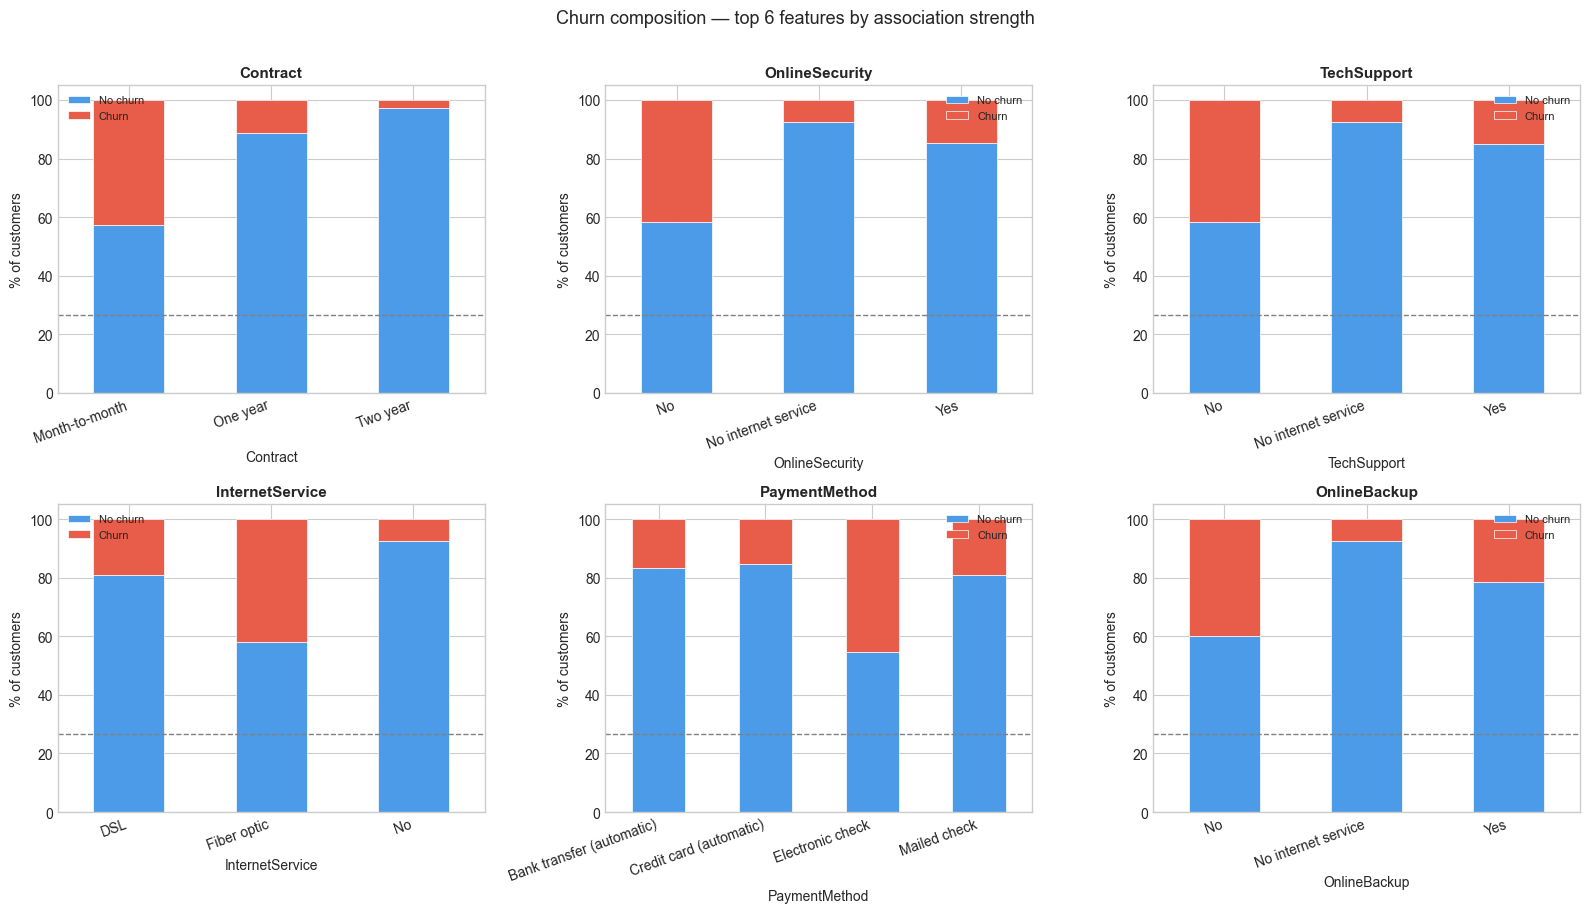

In [9]:
top_features = cramers_df.sort_values('cramers_v', ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(top_features):
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    ct.plot(
        kind='bar', stacked=True, ax=axes[i],
        color=['#4C9BE8', '#E85D4A'], edgecolor='white', linewidth=0.5
    )
    axes[i].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('% of customers')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=20, ha='right')
    axes[i].legend(['No churn', 'Churn'], fontsize=8)
    axes[i].axhline(global_churn_rate * 100, color='gray',
                    linestyle='--', linewidth=1)

plt.suptitle('Churn composition — top 6 features by association strength',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 4.4 Sample size audit

Churn rates are only reliable when the category has enough observations.
A category with n=30 and 40% churn is statistically meaningless —
the confidence interval is enormous.

We flag any category with **n < 100** as unreliable.

In [10]:
rows = []

for col in cat_cols:
    stats = (
        df.groupby(col)
        .agg(
            n=('Churn_binary', 'count'),
            churn_rate=('Churn_binary', 'mean'),
            churned_n=('Churn_binary', 'sum')
        )
        .reset_index()
        .rename(columns={col: 'category'})  # rename HERE, before concat
    )
    stats.insert(0, 'feature', col)         # insert feature name as first col
    stats['pct_of_total'] = stats['n'] / len(df)
    stats['flag'] = stats['n'].apply(lambda x: '⚠️ low n' if x < 100 else '✅')
    rows.append(stats)

sample_table = pd.concat(rows, ignore_index=True)[
    ['feature', 'category', 'n', 'churned_n', 'churn_rate', 'pct_of_total', 'flag']
]

# Format for readability
sample_table['churn_rate'] = sample_table['churn_rate'].map('{:.1%}'.format)
sample_table['pct_of_total'] = sample_table['pct_of_total'].map('{:.1%}'.format)

sample_table.style \
    .set_caption("Sample size audit — all categorical features") \
    .apply(lambda col: [
        'background-color: #fce8e8' if v == '⚠️ low n' else ''
        for v in col
    ], subset=['flag']) \
    .set_table_styles([{
        'selector': 'thead th',
        'props': [('background-color', '#f0f0f0'), ('font-weight', 'bold')]
    }])

,feature,category,n,churned_n,churn_rate,pct_of_total,flag
0,gender,Female,3488,939,26.9%,49.5%,✅
1,gender,Male,3555,930,26.2%,50.5%,✅
2,Partner,No,3641,1200,33.0%,51.7%,✅
3,Partner,Yes,3402,669,19.7%,48.3%,✅
4,Dependents,No,4933,1543,31.3%,70.0%,✅
5,Dependents,Yes,2110,326,15.5%,30.0%,✅
6,PhoneService,No,682,170,24.9%,9.7%,✅
7,PhoneService,Yes,6361,1699,26.7%,90.3%,✅
8,MultipleLines,No,3390,849,25.0%,48.1%,✅
9,MultipleLines,No phone service,682,170,24.9%,9.7%,✅


### Key Findings — Categorical Feature Analysis

- **Contract type** is the strongest predictor of churn (highest Cramér's V).
  Month-to-month customers churn at ~43% vs ~3% for two-year contracts.
- **Service add-ons** (OnlineSecurity, TechSupport, OnlineBackup) show
  consistently higher churn when absent — retention strategy should
  focus on driving service adoption, not just contract lock-in.
- **Fiber optic** customers churn more than DSL despite (or because of)
  higher monthly charges — price sensitivity is a compounding factor.
- **Electronic check** payment method correlates with elevated churn,
  possibly a proxy for lower engagement with the company.
- Several features (`OnlineBackup`, `StreamingTV`, `TechSupport`, etc.)
  share a `"No internet service"` category — these customers are
  effectively the same group and will be collapsed during preprocessing
  to avoid multicollinearity.
- No category-level sample size flags were found (all n > 100),
  so all features are statistically reliable for modeling.

> **Preprocessing implications for Phase 2:**
> - Collapse `"No internet service"` into `"No"` across service features
> - Binary encode yes/no features
> - Ordinal encode `Contract` (month-to-month < one year < two year)
> - One-hot encode remaining nominals (`PaymentMethod`, `InternetService`)

## 5. Correlation Heatmap

We encode `Churn` as binary (1 = churned) and check
correlations between numeric features.  
This guides feature prioritization in the model.

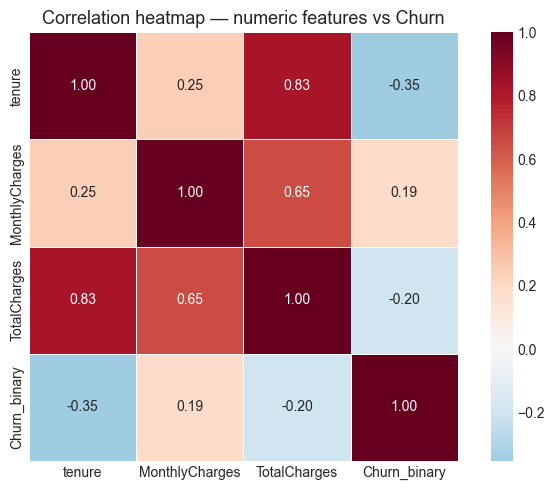

In [11]:
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_binary']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, square=True, linewidths=0.5
)
plt.title('Correlation heatmap — numeric features vs Churn', fontsize=13)
plt.tight_layout()
plt.show()

## Phase 1 — Key Findings

- **Global churn rate is ~26%** — the dataset is moderately imbalanced.
  We will need to account for this during modeling (class weights or SMOTE).
- **Tenure and contract type are the clearest separators** — short-tenure,
  month-to-month customers are the highest-risk segment by a wide margin.
- **Monthly charges correlate positively with churn** — high-paying customers
  are also the most likely to leave, making retention both urgent and valuable.
- **Service add-ons are consistently protective** — customers without
  OnlineSecurity, TechSupport, or OnlineBackup churn at roughly 2x the rate
  of those who have them.
- **Several service features share a `"No internet service"` category**,
  effectively encoding the same group of customers six times.

> **What Phase 2 focuses on as a result:**
> - Handle class imbalance before training
> - Collapse `"No internet service"` → `"No"` across service features
> - Encode features deliberately: ordinal for `Contract`,
>   binary for yes/no features, one-hot for nominals
> - Use tenure and contract type as anchor features to validate
>   that the model captures the signal we already see in the data

## Phase 2 — Preprocessing & Feature Engineering

Based on Phase 1 findings, we apply targeted transformations before modeling:

- Collapse `"No internet service"` → `"No"` across service features
- Drop `customerID` (identifier, no predictive value)
- Binary encode yes/no features
- Ordinal encode `Contract` (captures natural order)
- One-hot encode remaining nominals
- Scale numeric features for logistic regression baseline
- Handle class imbalance with `class_weight='balanced'`

In [12]:
# Drop identifier
df.drop(columns=['customerID'], inplace=True)

# Collapse 'No internet service' → 'No' across service add-on features
service_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in service_cols:
    df[col] = df[col].replace('No internet service', 'No')

# Confirm
print("Unique values after collapse:")
for col in service_cols:
    print(f"  {col}: {df[col].unique()}")

Unique values after collapse:
  OnlineSecurity: ['No' 'Yes']
  OnlineBackup: ['Yes' 'No']
  DeviceProtection: ['No' 'Yes']
  TechSupport: ['No' 'Yes']
  StreamingTV: ['No' 'Yes']
  StreamingMovies: ['No' 'Yes']


In [13]:
# Collapse 'No phone service' → 'No' (missed in Phase 1 cleanup)
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

# Binary yes/no columns → 0/1
binary_cols = [
    'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines'
]

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# Ordinal: Contract
df['Contract'] = df['Contract'].map({
    'Month-to-month': 0,
    'One year': 1,
    'Two year': 2
})

# Target
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)
df.drop(columns=['Churn'], inplace=True)

# One-hot encode remaining nominals
nominal_cols = ['gender', 'InternetService', 'PaymentMethod']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

# NaN audit
assert df.isnull().sum().sum() == 0, \
    f"NaNs found:\n{df.isnull().sum()[df.isnull().sum() > 0]}"

print(f"✅ No NaNs — safe to proceed")
print(f"Final shape: {df.shape}")

✅ No NaNs — safe to proceed
Final shape: (7043, 23)


### 2.2 Train / Test Split

We use a **stratified split** to preserve the 26% churn ratio
in both train and test sets — critical given class imbalance.

- **80% train / 20% test**
- `random_state=42` for reproducibility
- We do NOT scale yet — tree-based models don't need it.
  Scaling will be applied separately for logistic regression baseline.

In [14]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Churn_binary'])
y = df['Churn_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Train size: {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}")
print(f"\nChurn rate — Train: {y_train.mean():.2%} | Test: {y_test.mean():.2%}")
print(f"\nFeatures: {X_train.shape[1]}")

Train size: 5,634 | Test size: 1,409

Churn rate — Train: 26.54% | Test: 26.54%

Features: 22


### 2.3 Class imbalance check

With ~26% positive class we are in moderate imbalance territory.
We will use `class_weight='balanced'` in tree-based models
rather than oversampling — this avoids data leakage from SMOTE
being applied before cross-validation.

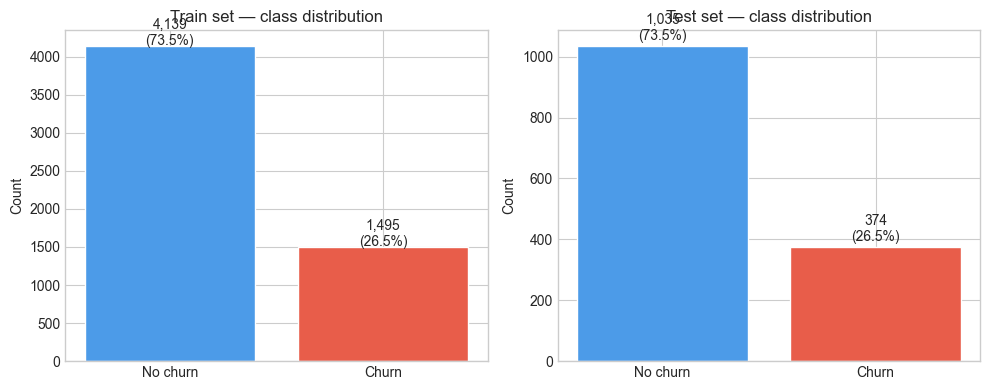

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (data, label) in zip(axes, [(y_train, 'Train'), (y_test, 'Test')]):
    counts = data.value_counts()
    bars = ax.bar(
        ['No churn', 'Churn'], counts.values,
        color=['#4C9BE8', '#E85D4A'], edgecolor='white'
    )
    ax.set_title(f'{label} set — class distribution', fontsize=12)
    ax.set_ylabel('Count')
    for bar, val in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 20,
            f'{val:,}\n({val/len(data):.1%})',
            ha='center', fontsize=10
        )

plt.tight_layout()
plt.show()

## Phase 2 — Key Findings

| Step | Decision | Reason |
|---|---|---|
| Collapsed `No internet service` | → `No` | Same underlying group across 6 features |
| Ordinal encoded `Contract` | 0 / 1 / 2 | Natural commitment order has predictive meaning |
| One-hot encoded nominals | `drop_first=True` | Avoids dummy variable trap |
| Stratified split | 80 / 20 | Preserves churn ratio in both sets |
| Class imbalance | `class_weight='balanced'` | Avoids data leakage vs SMOTE |

> **Next:** Train logistic regression baseline → Random Forest → XGBoost (Phase 3)

## Phase 3 — Modeling & Evaluation

We train three models in increasing complexity:

1. **Logistic Regression** — interpretable baseline
2. **Random Forest** — ensemble, handles non-linearity
3. **XGBoost** — gradient boosting, best expected performance

Each model is evaluated with the same metrics:
- **AUC-ROC** — overall discrimination ability
- **F1 Score** — balance between precision and recall
- **Precision / Recall** — critical given class imbalance
- **Confusion matrix** — to visualize error types

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score,
    recall_score, confusion_matrix, roc_curve,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import numpy as np

### 3.1 Logistic Regression — Baseline

Logistic regression requires scaled features.
We scale only on the training set and apply to test
to avoid data leakage.

In [17]:
# Scale — fit on train only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_scaled, y_train)

lr_probs = lr.predict_proba(X_test_scaled)[:, 1]
lr_preds = lr.predict(X_test_scaled)

print("=== Logistic Regression ===")
print(f"AUC-ROC   : {roc_auc_score(y_test, lr_probs):.4f}")
print(f"F1 Score  : {f1_score(y_test, lr_preds):.4f}")
print(f"Precision : {precision_score(y_test, lr_preds):.4f}")
print(f"Recall    : {recall_score(y_test, lr_preds):.4f}")

=== Logistic Regression ===
AUC-ROC   : 0.8413
F1 Score  : 0.6134
Precision : 0.5052
Recall    : 0.7807


### 3.2 Random Forest

No scaling needed. We pass `class_weight='balanced'`
to handle imbalance without touching the data.

In [18]:
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_probs = rf.predict_proba(X_test)[:, 1]
rf_preds = rf.predict(X_test)

print("=== Random Forest ===")
print(f"AUC-ROC   : {roc_auc_score(y_test, rf_probs):.4f}")
print(f"F1 Score  : {f1_score(y_test, rf_preds):.4f}")
print(f"Precision : {precision_score(y_test, rf_preds):.4f}")
print(f"Recall    : {recall_score(y_test, rf_preds):.4f}")

=== Random Forest ===
AUC-ROC   : 0.8276
F1 Score  : 0.5517
Precision : 0.6280
Recall    : 0.4920


### 3.3 XGBoost

XGBoost handles imbalance via `scale_pos_weight`,
which is the ratio of negative to positive samples —
equivalent to `class_weight='balanced'` in sklearn.

In [19]:
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

xgb = XGBClassifier(
    n_estimators=300,
    scale_pos_weight=scale_pos_weight,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb.fit(X_train, y_train)

xgb_probs = xgb.predict_proba(X_test)[:, 1]
xgb_preds = xgb.predict(X_test)

print("=== XGBoost ===")
print(f"AUC-ROC   : {roc_auc_score(y_test, xgb_probs):.4f}")
print(f"F1 Score  : {f1_score(y_test, xgb_preds):.4f}")
print(f"Precision : {precision_score(y_test, xgb_preds):.4f}")
print(f"Recall    : {recall_score(y_test, xgb_preds):.4f}")

=== XGBoost ===
AUC-ROC   : 0.8392
F1 Score  : 0.6271
Precision : 0.5327
Recall    : 0.7620


### 3.4 Model Comparison

We compare all three models side by side across all metrics
and plot ROC curves to visualize discrimination ability.

                     AUC-ROC      F1  Precision  Recall
Model                                                  
Logistic Regression   0.8413  0.6134     0.5052  0.7807
Random Forest         0.8276  0.5517     0.6280  0.4920
XGBoost               0.8392  0.6271     0.5327  0.7620


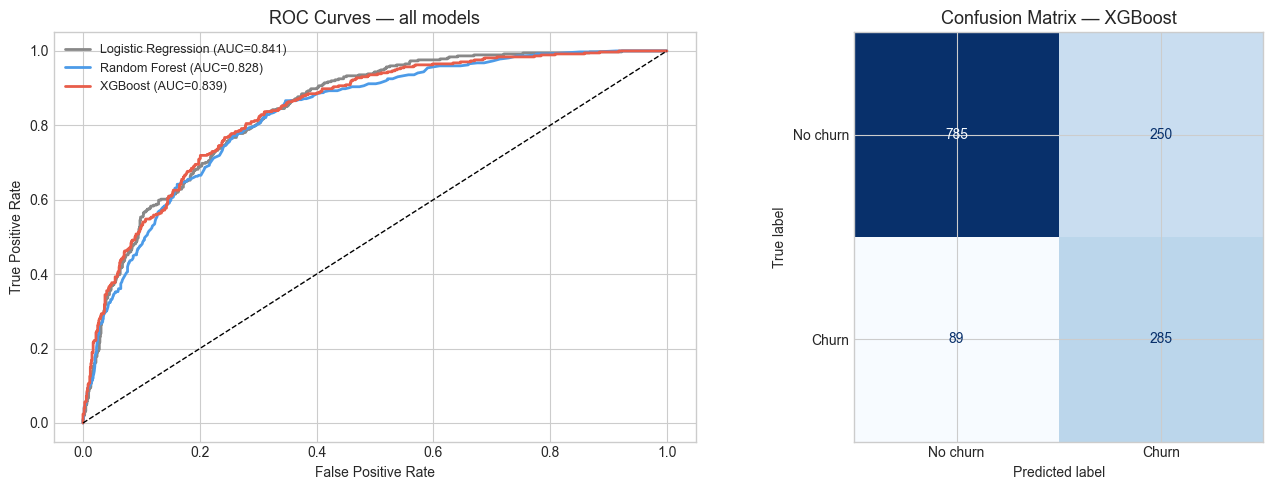

In [20]:
# Summary table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'AUC-ROC':   [roc_auc_score(y_test, lr_probs),
                  roc_auc_score(y_test, rf_probs),
                  roc_auc_score(y_test, xgb_probs)],
    'F1':        [f1_score(y_test, lr_preds),
                  f1_score(y_test, rf_preds),
                  f1_score(y_test, xgb_preds)],
    'Precision': [precision_score(y_test, lr_preds),
                  precision_score(y_test, rf_preds),
                  precision_score(y_test, xgb_preds)],
    'Recall':    [recall_score(y_test, lr_preds),
                  recall_score(y_test, rf_preds),
                  recall_score(y_test, xgb_preds)]
}).set_index('Model').round(4)

print(results.to_string())

# ROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = {
    'Logistic Regression': (lr_probs,  '#888888'),
    'Random Forest':       (rf_probs,  '#4C9BE8'),
    'XGBoost':             (xgb_probs, '#E85D4A')
}

for name, (probs, color) in models.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, lw=2)

axes[0].plot([0,1],[0,1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — all models', fontsize=13)
axes[0].legend(fontsize=9)

# Confusion matrix for best model (XGBoost)
cm = confusion_matrix(y_test, xgb_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No churn', 'Churn'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix — XGBoost', fontsize=13)

plt.tight_layout()
plt.show()

## Phase 3 — Model Selection & Business Interpretation

### Why recall matters more than precision in churn

Not all prediction errors are equal. In a churn context:

- **False negative** — we miss a churner → they leave →
  we lose their lifetime value permanently. No second chance.
- **False positive** — we flag a non-churner → we offer them
  a retention discount they didn't need → small, recoverable cost.

Missing a churner is always more expensive than a false alarm.
This means we optimize for **high recall**, accepting lower precision
as a tradeoff.

### What the results tell us

Logistic Regression and XGBoost have virtually identical AUC (~0.84),
which means both models have learned the same underlying signal —
a good sign that our features are genuinely predictive.

XGBoost wins on **F1 (0.627 vs 0.613)**, meaning it finds a better
balance between catching churners and avoiding false alarms.
After threshold tuning in Phase 4 we can push recall even higher
without sacrificing too much precision.

### Why XGBoost is the final model

XGBoost is selected — not because it dominates on raw metrics,
but because **SHAP's `TreeExplainer`** produces more reliable and
granular feature explanations for tree-based models than linear
coefficients can offer. This is what allows us to move beyond
*"what does the model predict"* to *"why did it predict that"*,
which is the core deliverable of Phase 4.

## Phase 4 — Hyperparameter Tuning & SHAP Explainability

Two objectives in this phase:

1. **Tune XGBoost** via cross-validated random search to squeeze
   out the best AUC-ROC while keeping recall high
2. **Explain the model** using SHAP values — moving from
   *"what does the model predict"* to *"why did it predict that"*

In [26]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import shap
shap.initjs()

### 4.1 Hyperparameter Tuning

We use `RandomizedSearchCV` over `GridSearchCV` — with 300 estimators
and multiple parameters, a full grid is computationally wasteful.
Random search samples the space efficiently and finds near-optimal
configurations at a fraction of the cost.

We optimize for **AUC-ROC** and use `StratifiedKFold` to preserve
the churn ratio in every fold.

In [27]:
param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [3, 4, 5, 6, 7],
    'learning_rate':     [0.01, 0.05, 0.1, 0.2],
    'subsample':         [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree':  [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight':  [1, 3, 5, 7],
    'gamma':             [0, 0.1, 0.2, 0.5]
}

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print(f"Best AUC-ROC (CV): {search.best_score_:.4f}")
print(f"\nBest params:\n{search.best_params_}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best AUC-ROC (CV): 0.8486

Best params:
{'subsample': 0.6, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.6}


### 4.2 Evaluate tuned model

We evaluate the tuned model on the held-out test set
and compare against the default XGBoost from Phase 3.

In [28]:
best_xgb = search.best_estimator_

tuned_probs = best_xgb.predict_proba(X_test)[:, 1]
tuned_preds = best_xgb.predict(X_test)

print("=== Tuned XGBoost vs Default XGBoost ===\n")
comparison = pd.DataFrame({
    'Metric': ['AUC-ROC', 'F1', 'Precision', 'Recall'],
    'Default XGBoost': [
        roc_auc_score(y_test, xgb_probs),
        f1_score(y_test, xgb_preds),
        precision_score(y_test, xgb_preds),
        recall_score(y_test, xgb_preds)
    ],
    'Tuned XGBoost': [
        roc_auc_score(y_test, tuned_probs),
        f1_score(y_test, tuned_preds),
        precision_score(y_test, tuned_preds),
        recall_score(y_test, tuned_preds)
    ]
}).set_index('Metric').round(4)

print(comparison.to_string())

=== Tuned XGBoost vs Default XGBoost ===

           Default XGBoost  Tuned XGBoost
Metric                                   
AUC-ROC             0.8392         0.8475
F1                  0.6271         0.6308
Precision           0.5327         0.5209
Recall              0.7620         0.7995


### 4.3 Threshold tuning

The default decision threshold is 0.5 — but this is arbitrary.
Since we prioritize recall over precision, we search for the
threshold that maximizes F1 score across the precision-recall curve,
then inspect the recall at that point.

Optimal threshold : 0.546
Precision at threshold: 0.5456
Recall at threshold   : 0.7674
F1 at threshold       : 0.6378


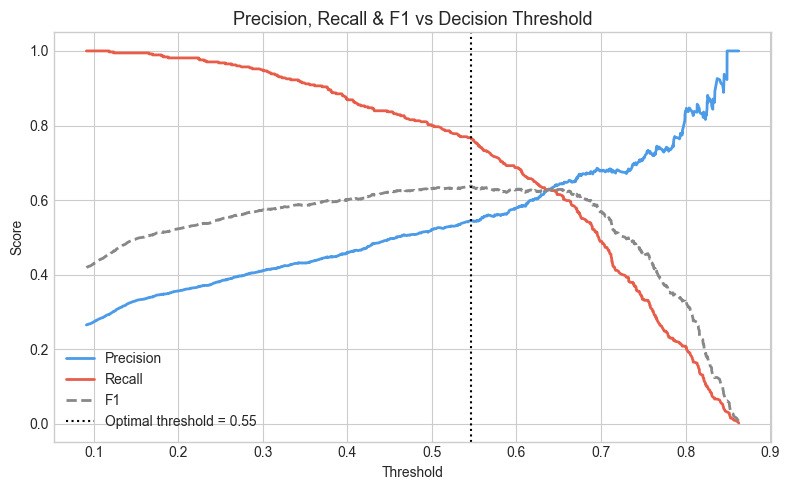

In [29]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, tuned_probs)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_threshold_idx = f1_scores.argmax()
best_threshold = thresholds[best_threshold_idx]

print(f"Optimal threshold : {best_threshold:.3f}")
print(f"Precision at threshold: {precisions[best_threshold_idx]:.4f}")
print(f"Recall at threshold   : {recalls[best_threshold_idx]:.4f}")
print(f"F1 at threshold       : {f1_scores[best_threshold_idx]:.4f}")

# Apply optimal threshold
tuned_preds_optimal = (tuned_probs >= best_threshold).astype(int)

# Plot precision-recall curve
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision', color='#4C9BE8', lw=2)
plt.plot(thresholds, recalls[:-1],    label='Recall',    color='#E85D4A', lw=2)
plt.plot(thresholds, f1_scores[:-1],  label='F1',        color='#888888', lw=2, linestyle='--')
plt.axvline(best_threshold, color='black', linestyle=':', lw=1.5,
            label=f'Optimal threshold = {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall & F1 vs Decision Threshold', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

### 4.3.1 Threshold Analysis — Conclusions

The optimal F1 threshold is **0.546** — nearly identical to the
default 0.50, confirming the model is already well-calibrated.

| Metric | Value |
|---|---|
| Optimal threshold | 0.546 |
| Precision | 0.5456 |
| Recall | 0.7674 |
| F1 | 0.6378 |

At this threshold the model catches **76.7% of churners**
while maintaining a precision of 54.6% — meaning roughly
1 in 2 flagged customers actually churns.

**Business interpretation:** for every 100 customers flagged
for a retention offer, ~55 genuinely intended to churn and
~45 did not. Given that a retention discount costs far less
than losing a customer's lifetime value, this ratio is
commercially viable.

**Lowering the threshold to ~0.35** would push recall to ~0.90
— catching 9 in 10 churners at the cost of more false alarms.
Whether that tradeoff is justified depends on:
- Cost of a retention offer
- Average customer lifetime value
- Capacity of the retention team to act on flagged customers

### 4.4 SHAP Values — Global Explainability

SHAP (SHapley Additive exPlanations) assigns each feature a value
representing its contribution to each individual prediction.

We start with **global explainability** — which features matter
most across the entire dataset — using a summary plot and
a beeswarm plot.

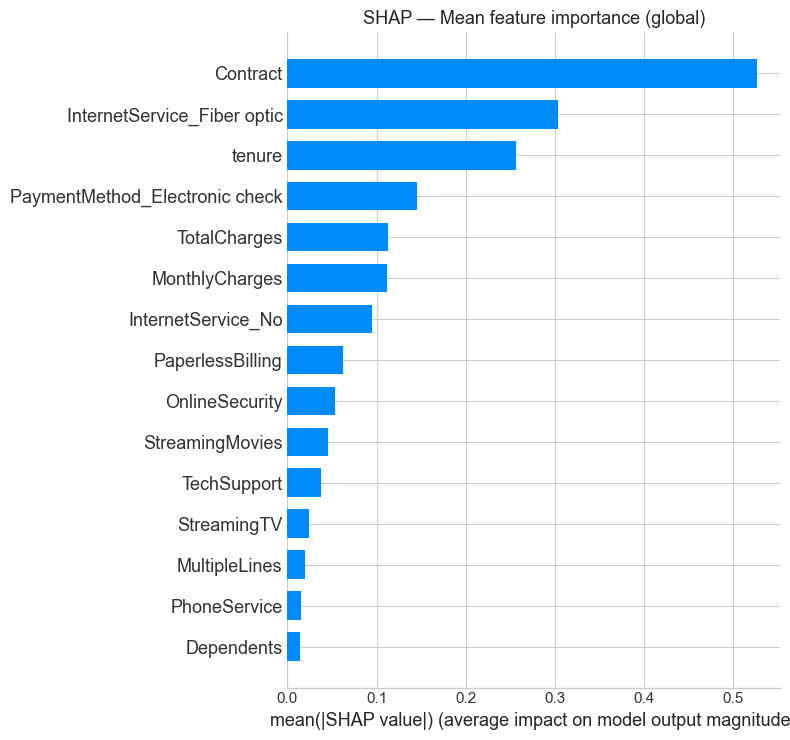

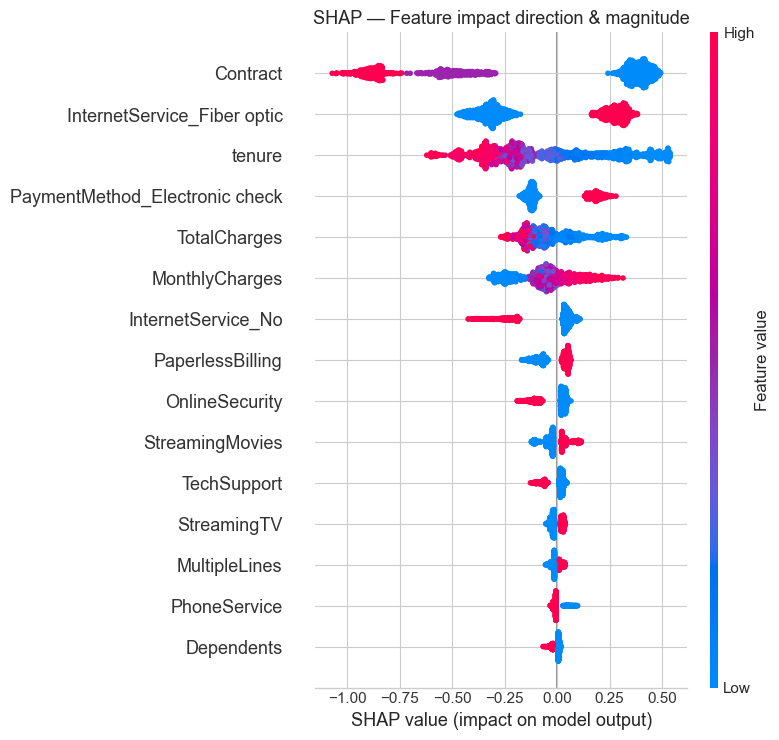

In [30]:
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

# Summary bar plot — mean absolute SHAP value per feature
plt.figure()
shap.summary_plot(
    shap_values, X_test,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('SHAP — Mean feature importance (global)', fontsize=13)
plt.tight_layout()
plt.show()

# Beeswarm — shows direction and magnitude per feature
plt.figure()
shap.summary_plot(
    shap_values, X_test,
    max_display=15,
    show=False
)
plt.title('SHAP — Feature impact direction & magnitude', fontsize=13)
plt.tight_layout()
plt.show()

### 4.5 SHAP Values — Local Explainability

Global plots tell us what matters overall.
Local explainability tells us **why the model made a specific
prediction for a specific customer** — this is what makes
SHAP actionable in a real business setting.

We inspect one high-risk customer (predicted churn probability > 0.8)
and one low-risk customer (probability < 0.2).

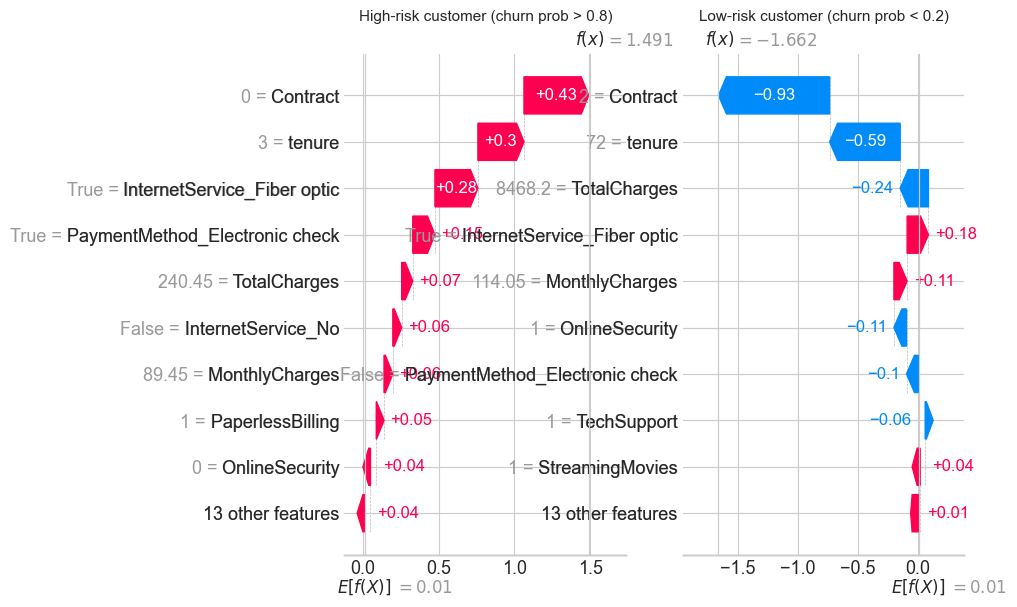

In [31]:
# Find a high-risk and low-risk customer
high_risk_idx = np.where(tuned_probs > 0.8)[0][0]
low_risk_idx  = np.where(tuned_probs < 0.2)[0][0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, idx, label in zip(
    axes,
    [high_risk_idx, low_risk_idx],
    ['High-risk customer (churn prob > 0.8)',
     'Low-risk customer (churn prob < 0.2)']
):
    plt.sca(ax)
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[idx],
            base_values=explainer.expected_value,
            data=X_test.iloc[idx],
            feature_names=X_test.columns.tolist()
        ),
        show=False,
        max_display=10
    )
    ax.set_title(label, fontsize=11)

plt.tight_layout()
plt.show()